# Preprocesamiento de Datos para Minería de Datos
## Dataset: Telco Customer Churn (IBM)

**Fuente:** [Kaggle — Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

**Tarea de minería de datos:** Predecir si un cliente de una empresa de telecomunicaciones cancelará su servicio (**Churn = Yes / No**) → Clasificación binaria

---

### ¿Por qué el preprocesamiento es clave?

El dato en crudo raramente está listo para ser analizado. Antes de aplicar cualquier algoritmo de minería de datos, es fundamental identificar y corregir los problemas de calidad del dataset. Un modelo entrenado sobre datos sucios producirá resultados poco confiables, sin importar cuán sofisticado sea el algoritmo.

### Objetivos del notebook

1. Realizar un **Análisis Exploratorio de Datos (EDA)** para comprender el dataset
2. Identificar y tratar:
   - Valores faltantes
   - Formatos incorrectos
   - Inconsistencias de codificación
   - Datos duplicados
   - Valores atípicos (outliers)
3. **Justificar cada decisión** en el contexto de la tarea de clasificación posterior
4. Producir un dataset limpio y listo para la etapa de minería de datos

---

### Descripción del dataset

| Característica | Detalle |
|---|---|
| Filas | 7,043 clientes |
| Columnas | 21 variables |
| Variable objetivo | `Churn` (Yes/No) |
| Dominio | Empresa de telecomunicaciones |

**Grupos de variables:**
- **Datos demográficos:** gender, SeniorCitizen, Partner, Dependents
- **Servicios contratados:** PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies
- **Información de cuenta:** Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges, tenure
- **Variable objetivo:** Churn


---
## 0. Instalación e importación de librerías

In [1]:
# Instalación (ejecutar solo si es necesario)
# !pip install pandas numpy matplotlib seaborn
print('Si las librerías ya están instaladas, continúa con la siguiente celda.')

Si las librerías ya están instaladas, continúa con la siguiente celda.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualizaciones
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 30)

print('✓ Librerías importadas correctamente.')

✓ Librerías importadas correctamente.


---
## 1. Carga del dataset

### Instrucciones de descarga
1. Ingresa a: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
2. Descarga el archivo `WA_Fn-UseC_-Telco-Customer-Churn.csv`
3. Colócalo en una carpeta datasets a nivel del notebook

In [3]:
# Cargar el dataset
df = pd.read_csv('datasets/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f'Dataset cargado exitosamente.')
print(f'Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas')

Dataset cargado exitosamente.
Dimensiones: 7043 filas × 21 columnas


In [4]:
# Vista de las primeras 5 filas
print('Primeras 5 filas del dataset:')
df.head()

Primeras 5 filas del dataset:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Vista de las últimas 5 filas para detectar posibles problemas al final del archivo
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


---
## 2. Inspección inicial del dataset

Antes de cualquier análisis, revisamos la **estructura**, los **tipos de datos** y el **estado general** del dataset.
Este paso nos permite tener una primera idea de los problemas de calidad presentes.


In [6]:
# Información general: tipos de datos, valores no nulos por columna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Observaciones iniciales de `df.info()`

> **Atención:** La columna `TotalCharges` aparece como tipo `object` (texto), cuando debería ser numérica (`float64`).  
> Esto es una señal de alerta que investigaremos en detalle más adelante.

> `SeniorCitizen` aparece como `int64` (0 y 1), mientras que variables similares como `Partner` y `Dependents` usan `Yes/No`.
> Esta inconsistencia de codificación también deberá corregirse.


In [7]:
# Tipos de datos por columna
print('Tipos de datos:')
print(df.dtypes.to_string())

Tipos de datos:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object


In [8]:
# Estadísticas descriptivas de variables numéricas
df.describe().round(2)

,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75


In [9]:
# Estadísticas de variables categóricas
df.describe(include='object').T

,count,unique,top,freq
customerID,7043,7043,7590-VHVEG,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


---
## 3. Análisis Exploratorio de Datos (EDA)

El EDA nos permite comprender la distribución de las variables, identificar patrones y detectar anomalías.
Trabajaremos por grupos: primero la variable objetivo, luego variables numéricas y finalmente categóricas.


### 3.1 Variable objetivo: Churn

Distribución de Churn:
       Cantidad  Porcentaje (%)
Churn                          
No         5174           73.46
Yes        1869           26.54


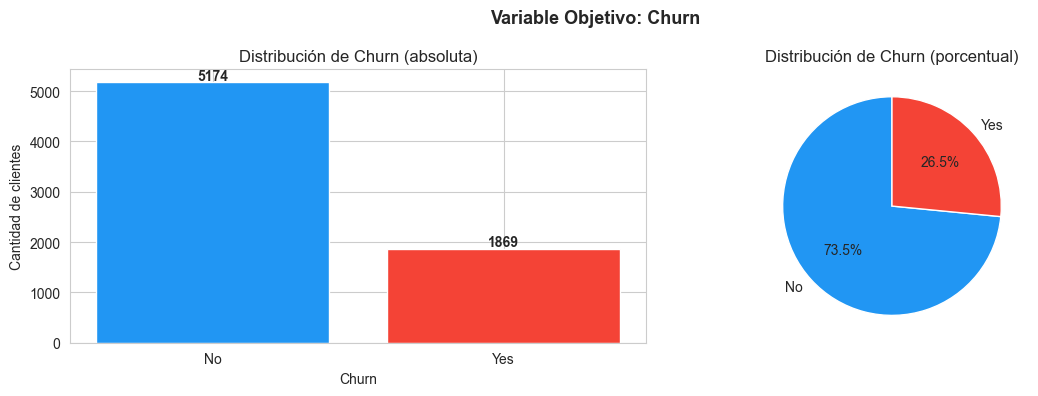


⚠ Observación: El dataset está desbalanceado. Solo el ~26.5% de clientes abandonó el servicio.
Esto es relevante para la tarea de clasificación posterior (se deberán aplicar técnicas de balanceo).


In [10]:
# Distribución de la variable objetivo
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print('Distribución de Churn:')
print(pd.DataFrame({'Cantidad': churn_counts, 'Porcentaje (%)': churn_pct.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras
axes[0].bar(churn_counts.index, churn_counts.values, color=['#2196F3', '#F44336'])
axes[0].set_title('Distribución de Churn (absoluta)')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Cantidad de clientes')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Gráfico de torta
axes[1].pie(churn_counts.values, labels=churn_counts.index,
            autopct='%1.1f%%', colors=['#2196F3', '#F44336'], startangle=90)
axes[1].set_title('Distribución de Churn (porcentual)')

plt.suptitle('Variable Objetivo: Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n⚠ Observación: El dataset está desbalanceado. Solo el ~26.5% de clientes abandonó el servicio.')
print('Esto es relevante para la tarea de clasificación posterior (se deberán aplicar técnicas de balanceo).')

### 3.2 Variables numéricas

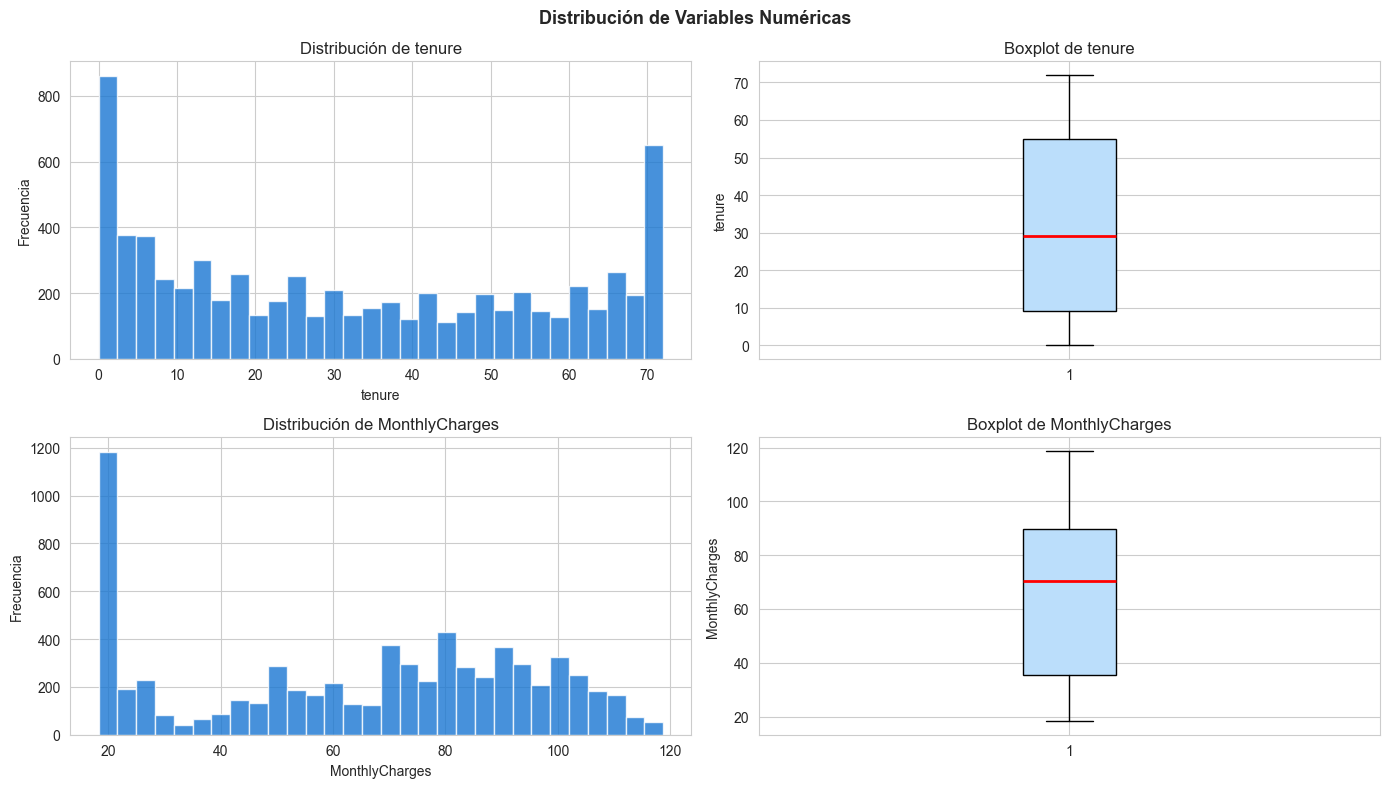

In [11]:
# Identificar variables numéricas (excluyendo TotalCharges por ahora por su tipo incorrecto)
vars_numericas = ['tenure', 'MonthlyCharges']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, var in enumerate(vars_numericas):
    # Histograma
    axes[i][0].hist(df[var], bins=30, color='#1976D2', edgecolor='white', alpha=0.8)
    axes[i][0].set_title(f'Distribución de {var}')
    axes[i][0].set_xlabel(var)
    axes[i][0].set_ylabel('Frecuencia')
    
    # Boxplot
    axes[i][1].boxplot(df[var], patch_artist=True,
                       boxprops=dict(facecolor='#BBDEFB'),
                       medianprops=dict(color='red', linewidth=2))
    axes[i][1].set_title(f'Boxplot de {var}')
    axes[i][1].set_ylabel(var)

plt.suptitle('Distribución de Variables Numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

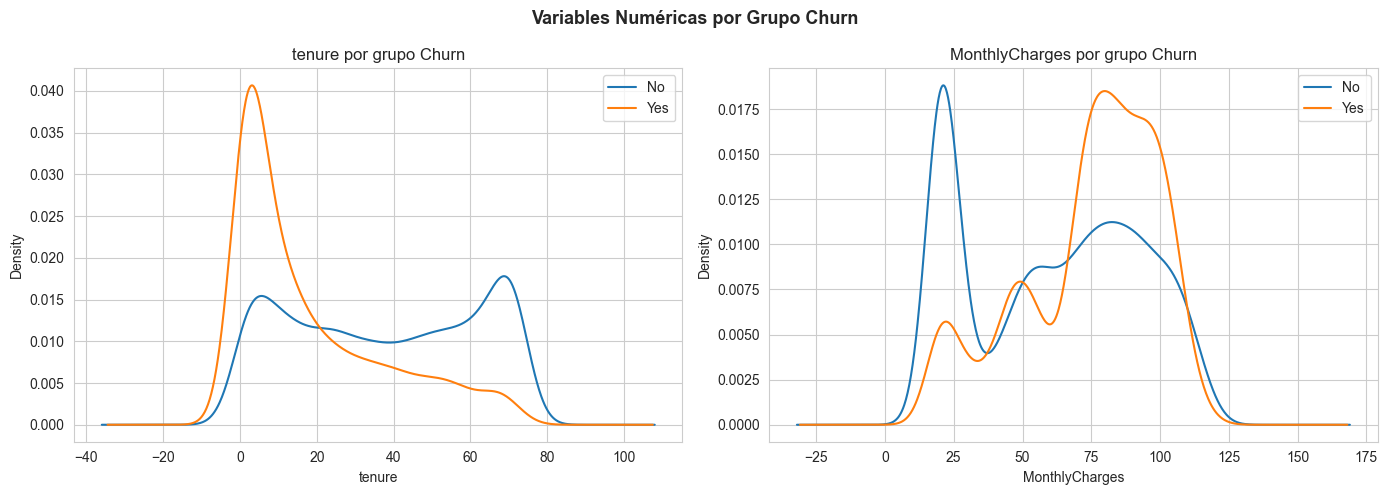

Estadísticas por grupo Churn:
       tenure                                            MonthlyCharges  \
        count   mean    std  min   25%   50%   75%   max          count   
Churn                                                                     
No     5174.0  37.57  24.11  0.0  15.0  38.0  61.0  72.0         5174.0   
Yes    1869.0  17.98  19.53  1.0   2.0  10.0  29.0  72.0         1869.0   

                                                        
        mean    std    min    25%    50%   75%     max  
Churn                                                   
No     61.27  31.09  18.25  25.10  64.43  88.4  118.75  
Yes    74.44  24.67  18.85  56.15  79.65  94.2  118.35  


In [12]:
# Comparar distribución por grupo Churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, var in enumerate(vars_numericas):
    df.groupby('Churn')[var].plot(kind='density', ax=axes[i], legend=True)
    axes[i].set_title(f'{var} por grupo Churn')
    axes[i].set_xlabel(var)

plt.suptitle('Variables Numéricas por Grupo Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Estadísticas por grupo Churn:')
print(df.groupby('Churn')[vars_numericas].describe().round(2))

### 3.3 Variables categóricas

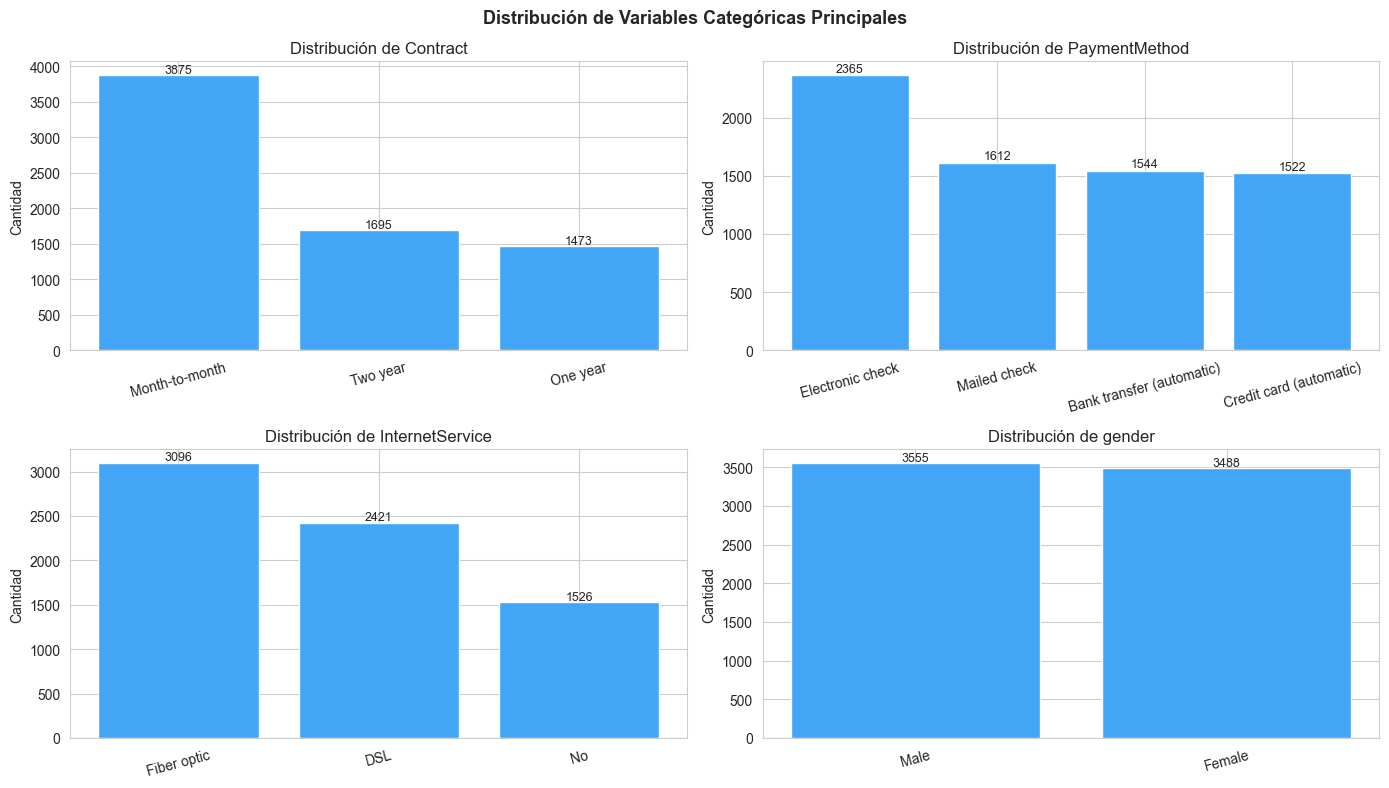

In [13]:
# Frecuencias de variables categóricas principales
vars_cat = ['Contract', 'PaymentMethod', 'InternetService', 'gender']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, var in enumerate(vars_cat):
    counts = df[var].value_counts()
    axes[i//2][i%2].bar(counts.index, counts.values, color='#42A5F5', edgecolor='white')
    axes[i//2][i%2].set_title(f'Distribución de {var}')
    axes[i//2][i%2].set_ylabel('Cantidad')
    axes[i//2][i%2].tick_params(axis='x', rotation=15)
    for j, v in enumerate(counts.values):
        axes[i//2][i%2].text(j, v + 30, str(v), ha='center', fontsize=9)

plt.suptitle('Distribución de Variables Categóricas Principales', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Identificación y tratamiento de problemas de calidad

En esta sección abordaremos de forma sistemática cada uno de los cinco problemas de calidad más comunes en datasets reales.
Para cada uno: **detectamos** el problema, **analizamos** su impacto y **aplicamos** la acción correctiva con su **justificación**.


---
### 4.1 Valores faltantes

Los valores faltantes son celdas sin información. Pueden ocurrir por errores de captura, datos no disponibles en el momento del registro, o problemas en la integración de fuentes.
Si no se tratan, la mayoría de los algoritmos de minería de datos los rechaza o produce errores.


In [14]:
# ── DETECCIÓN ──
# Verificación estándar con isnull()
nulos = df.isnull().sum()
print('Valores nulos por columna (detección estándar):')
print(nulos[nulos >= 0].to_string())
print(f'\nTotal de valores nulos detectados: {nulos.sum()}')

Valores nulos por columna (detección estándar):
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0

Total de valores nulos detectados: 0


**Resultado sorprendente:** `isnull()` reporta 0 valores nulos. ¿Significa que el dataset está completo?  
No necesariamente. Algunos valores faltantes están **disfrazados** como cadenas vacías `' '` en lugar de `NaN` real.  
Esto es común cuando los datos provienen de formularios o exportaciones de Excel/CSV.

> **Investigación necesaria:** Como `TotalCharges` está como `object`, sospechamos que contiene espacios vacíos. Verifiquemos.


In [15]:
# ── INVESTIGACIÓN PROFUNDA ──
# Convertir TotalCharges a numérico y forzar error donde no sea posible
total_charges_num = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Contar cuántos valores no se pudieron convertir (son los verdaderos faltantes)
faltantes_ocultos = total_charges_num.isnull().sum()
print(f'Valores faltantes ocultos en TotalCharges: {faltantes_ocultos}')

# Ver qué contienen esas filas
mask_faltantes = total_charges_num.isnull()
print('\nFilas con valores faltantes ocultos en TotalCharges:')
print(df[mask_faltantes][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']])

Valores faltantes ocultos en TotalCharges: 11

Filas con valores faltantes ocultos en TotalCharges:
      customerID  tenure  MonthlyCharges TotalCharges Churn
488   4472-LVYGI       0           52.55                 No
753   3115-CZMZD       0           20.25                 No
936   5709-LVOEQ       0           80.85                 No
1082  4367-NUYAO       0           25.75                 No
1340  1371-DWPAZ       0           56.05                 No
3331  7644-OMVMY       0           19.85                 No
3826  3213-VVOLG       0           25.35                 No
4380  2520-SGTTA       0           20.00                 No
5218  2923-ARZLG       0           19.70                 No
6670  4075-WKNIU       0           73.35                 No
6754  2775-SEFEE       0           61.90                 No


**Hallazgo clave:** Las 11 filas con `TotalCharges = ' '` corresponden a clientes con `tenure = 0`, es decir, **clientes que acaban de ingresar** y aún no tienen un cargo total registrado.  

**Análisis del impacto en la tarea de minería de datos:**
- Son solo 11 filas de 7,043 (0.15% del dataset)
- Representan clientes nuevos sin historial de pagos
- `TotalCharges` es una variable relevante para predecir churn, por lo que no podemos ignorarla

**Acción justificada:** Dado que son muy pocos registros y corresponden a clientes nuevos (tenure = 0) que no tienen cargo histórico, una opción válida es **imputar con 0.0** (coherente con que no han generado cargos aún). Otra opción es **eliminar estas filas** (su pequeño número no afecta el modelo).
En este caso optamos por imputar con 0.0 para preservar la información demográfica del cliente.


In [16]:
# ── ACCIÓN: Imputar TotalCharges = 0.0 donde tenure = 0 ──
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

# Verificar que ya no quedan faltantes
print(f'Valores nulos en TotalCharges después de imputar: {df["TotalCharges"].isnull().sum()}')
print(f'Tipo de dato actualizado: {df["TotalCharges"].dtype}')
print('\n✓ Valores faltantes tratados correctamente.')

Valores nulos en TotalCharges después de imputar: 0
Tipo de dato actualizado: float64

✓ Valores faltantes tratados correctamente.


---
### 4.2 Formato incorrecto

El formato de una variable debe ser coherente con su naturaleza. Una variable numérica guardada como texto impide calcular estadísticas, construir visualizaciones y alimentar algoritmos de Machine Learning.


In [17]:
# ── DETECCIÓN ──
# Verificar tipos de datos antes y después del tratamiento
print('Tipos de datos actuales de variables de cargos:')
print(df[['MonthlyCharges', 'TotalCharges']].dtypes)

print('\nEstadísticas de TotalCharges (ahora como float):')
print(df['TotalCharges'].describe().round(2))

Tipos de datos actuales de variables de cargos:
MonthlyCharges    float64
TotalCharges      float64
dtype: object

Estadísticas de TotalCharges (ahora como float):
count    7043.00
mean     2279.73
std      2266.79
min         0.00
25%       398.55
50%      1394.55
75%      3786.60
max      8684.80
Name: TotalCharges, dtype: float64


**Nota:** Al corregir los valores faltantes en el paso 4.1, ya convertimos `TotalCharges` a `float64`.  
Sin embargo, es importante documentar este paso de forma explícita porque en la práctica puede ocurrir con múltiples columnas y por distintas razones:

- **Fechas guardadas como texto:** `'2023-01-15'` → `datetime`
- **Números con símbolos:** `'$1,200'` → `1200.0`
- **Booleanos como enteros:** `1/0` → `True/False`

**Impacto en minería de datos:** Los algoritmos de clasificación requieren que las variables numéricas sean de tipo numérico. Si `TotalCharges` siguiera como `object`, no podría usarse directamente en modelos como regresión logística, árboles de decisión o redes neuronales.


In [18]:
# ── VERIFICACIÓN FINAL DE TIPOS ──
print('Tipos de datos del dataset (después de correcciones):')
print(df.dtypes.to_string())

Tipos de datos del dataset (después de correcciones):
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object


---
### 4.3 Inconsistencias de codificación

Las inconsistencias de codificación ocurren cuando variables del mismo tipo usan esquemas de representación distintos dentro del mismo dataset.  
Esto dificulta el análisis comparativo y puede introducir errores en la etapa de transformación.


In [19]:
# ── DETECCIÓN ──
# Comparar SeniorCitizen con otras variables binarias
print('Variable SeniorCitizen:')
print(df['SeniorCitizen'].value_counts())
print(f'Tipo: {df["SeniorCitizen"].dtype}')

print('\nVariable Partner (referencia):')
print(df['Partner'].value_counts())
print(f'Tipo: {df["Partner"].dtype}')

print('\n⚠ Problema: SeniorCitizen usa 0/1 mientras Partner, Dependents, PhoneService usan Yes/No.')

Variable SeniorCitizen:
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64
Tipo: int64

Variable Partner (referencia):
Partner
No     3641
Yes    3402
Name: count, dtype: int64
Tipo: object

⚠ Problema: SeniorCitizen usa 0/1 mientras Partner, Dependents, PhoneService usan Yes/No.


**Análisis del impacto:**
- Visualmente, un gráfico de `SeniorCitizen` mostraría `0` y `1` en lugar de etiquetas descriptivas
- En la etapa de transformación, las variables binarias Yes/No se codifican de una manera (Label Encoding) mientras que las numéricas podrían tratarse diferente
- Para el alumno o usuario que analiza el dataset, el significado de `0` y `1` no es inmediatamente claro

**Acción justificada:** Convertir `SeniorCitizen` a `Yes/No` para uniformidad con las demás variables binarias del dataset. Esto facilita el análisis y la interpretación de resultados.


In [20]:
# ── ACCIÓN: Convertir SeniorCitizen de 0/1 a No/Yes ──
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

# Verificar el cambio
print('SeniorCitizen después de la conversión:')
print(df['SeniorCitizen'].value_counts())
print(f'Tipo: {df["SeniorCitizen"].dtype}')
print('\n✓ Codificación corregida. Ahora es consistente con las demás variables binarias.')

SeniorCitizen después de la conversión:
SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64
Tipo: object

✓ Codificación corregida. Ahora es consistente con las demás variables binarias.


---
### 4.4 Datos duplicados

Los datos duplicados son filas que aparecen más de una vez en el dataset. Pueden ocurrir por:
- Errores en la integración de múltiples fuentes de datos
- Fallos en el proceso de carga (ETL)
- Errores de captura manual

**Impacto en minería de datos:** Los duplicados sesgan el modelo porque dan más peso artificial a ciertos patrones. Un cliente duplicado 3 veces influye 3 veces en el entrenamiento del algoritmo, como si fueran 3 clientes distintos.


In [21]:
# ── DETECCIÓN GENERAL ──
total_duplicados = df.duplicated().sum()
print(f'Total de filas completamente duplicadas: {total_duplicados}')

Total de filas completamente duplicadas: 0


In [22]:
# ── DETECCIÓN POR IDENTIFICADOR ÚNICO ──
# customerID debe ser único para cada cliente
ids_duplicados = df['customerID'].duplicated().sum()
print(f'customerID duplicados: {ids_duplicados}')

# Verificar que customerID realmente actúa como identificador único
print(f'Total de filas: {len(df)}')
print(f'customerIDs únicos: {df["customerID"].nunique()}')

if ids_duplicados == 0:
    print('\n✓ No se encontraron duplicados. Cada fila corresponde a un cliente único.')
else:
    print('\n⚠ Se encontraron duplicados. Aplicar df.drop_duplicates().')

customerID duplicados: 0
Total de filas: 7043
customerIDs únicos: 7043

✓ No se encontraron duplicados. Cada fila corresponde a un cliente único.


In [23]:
# ── BUENA PRÁCTICA: Mostrar cómo eliminarlos si existieran ──
# Aunque en este dataset no hay duplicados, es importante conocer el procedimiento
n_antes = len(df)
df = df.drop_duplicates()
n_despues = len(df)

print(f'Filas antes:  {n_antes}')
print(f'Filas después: {n_despues}')
print(f'Filas eliminadas: {n_antes - n_despues}')
print('\n✓ Verificación de duplicados completada.')

Filas antes:  7043
Filas después: 7043
Filas eliminadas: 0

✓ Verificación de duplicados completada.


---
### 4.5 Valores atípicos (Outliers)

Los valores atípicos son observaciones que se alejan significativamente del comportamiento general de los datos.
Pueden ser **errores de captura** (outliers espurios) o **casos reales pero inusuales** (outliers genuinos).

**Método de detección:** Diagrama de caja de Tukey (Boxplot) con la regla del Rango Intercuartil:
- **RIC** = Q3 − Q1
- **Límite Inferior** = Q1 − 1.5 × RIC
- **Límite Superior** = Q3 + 1.5 × RIC
- **Atípicos leves:** entre 1.5 y 3 veces el RIC
- **Atípicos extremos:** más de 3 veces el RIC


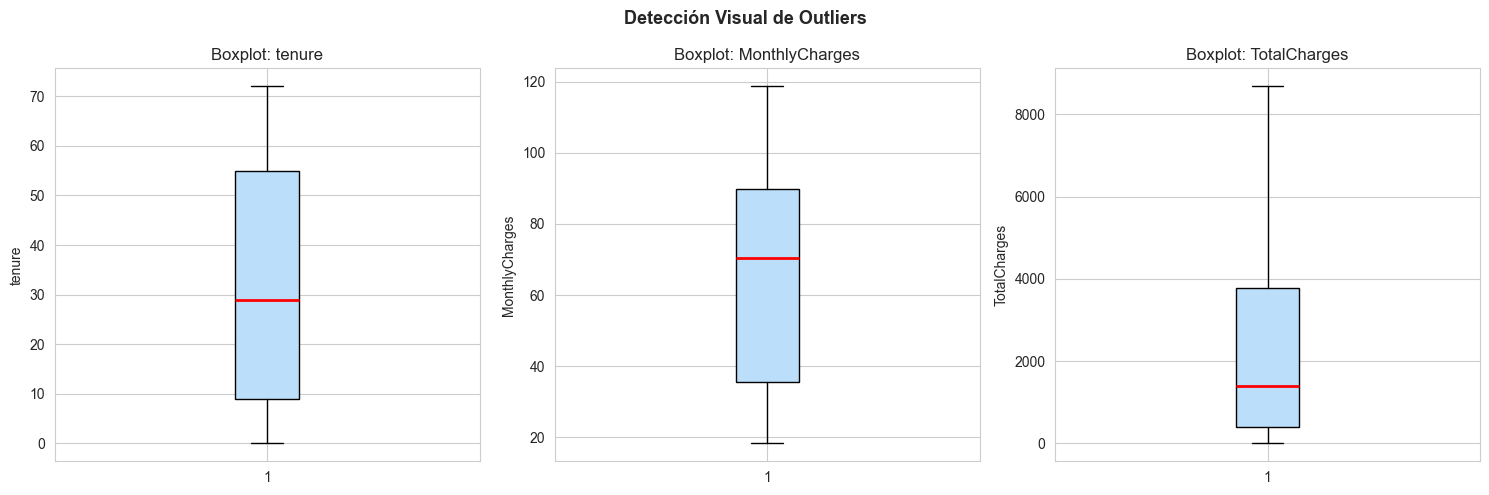

In [24]:
# ── DETECCIÓN VISUAL: Boxplots de variables numéricas ──
vars_num_completas = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, var in enumerate(vars_num_completas):
    axes[i].boxplot(df[var], patch_artist=True,
                    boxprops=dict(facecolor='#BBDEFB'),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='orange', markersize=5))
    axes[i].set_title(f'Boxplot: {var}')
    axes[i].set_ylabel(var)

plt.suptitle('Detección Visual de Outliers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
# ── DETECCIÓN CUANTITATIVA: Regla del RIC ──
def detectar_outliers(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    RIC = Q3 - Q1
    lim_inf = Q1 - 1.5 * RIC
    lim_sup = Q3 + 1.5 * RIC
    lim_inf_ext = Q1 - 3 * RIC
    lim_sup_ext = Q3 + 3 * RIC

    outliers_leves = df[
        ((df[columna] < lim_inf) & (df[columna] >= lim_inf_ext)) |
        ((df[columna] > lim_sup) & (df[columna] <= lim_sup_ext))
    ]
    outliers_extremos = df[
        (df[columna] < lim_inf_ext) | (df[columna] > lim_sup_ext)
    ]

    print(f'\n{'='*50}')
    print(f'Variable: {columna}')
    print(f'  Q1 = {Q1:.2f}  |  Q3 = {Q3:.2f}  |  RIC = {RIC:.2f}')
    print(f'  Límite Inferior = {lim_inf:.2f}  |  Límite Superior = {lim_sup:.2f}')
    print(f'  Límite Inferior Extremo = {lim_inf_ext:.2f}  |  Límite Superior Extremo = {lim_sup_ext:.2f}')
    print(f'  Outliers leves:   {len(outliers_leves)} ({len(outliers_leves)/len(df)*100:.2f}%)')
    print(f'  Outliers extremos: {len(outliers_extremos)} ({len(outliers_extremos)/len(df)*100:.2f}%)')

    return outliers_leves, outliers_extremos

for var in vars_num_completas:
    detectar_outliers(df, var)


Variable: tenure
  Q1 = 9.00  |  Q3 = 55.00  |  RIC = 46.00
  Límite Inferior = -60.00  |  Límite Superior = 124.00
  Límite Inferior Extremo = -129.00  |  Límite Superior Extremo = 193.00
  Outliers leves:   0 (0.00%)
  Outliers extremos: 0 (0.00%)

Variable: MonthlyCharges
  Q1 = 35.50  |  Q3 = 89.85  |  RIC = 54.35
  Límite Inferior = -46.02  |  Límite Superior = 171.38
  Límite Inferior Extremo = -127.55  |  Límite Superior Extremo = 252.90
  Outliers leves:   0 (0.00%)
  Outliers extremos: 0 (0.00%)

Variable: TotalCharges
  Q1 = 398.55  |  Q3 = 3786.60  |  RIC = 3388.05
  Límite Inferior = -4683.52  |  Límite Superior = 8868.67
  Límite Inferior Extremo = -9765.60  |  Límite Superior Extremo = 13950.75
  Outliers leves:   0 (0.00%)
  Outliers extremos: 0 (0.00%)


### Análisis e interpretación de los outliers encontrados

**`tenure` (meses de permanencia):** Sin outliers significativos. Los clientes tienen entre 0 y 72 meses, lo cual es un rango razonable y esperado en el dominio.

**`MonthlyCharges` (cargo mensual):** Posibles outliers en el extremo superior. Sin embargo, antes de eliminarlos debemos considerar que:
- Clientes con múltiples servicios contratados (internet de alta velocidad + TV + teléfono) naturalmente pagan más
- Estos casos son **outliers genuinos** (casos reales), no errores de captura

**`TotalCharges` (cargo total acumulado):** Los valores extremos corresponden a clientes con muchos meses de permanencia y cargos mensuales altos. Son coherentes con la combinación de `tenure` alto × `MonthlyCharges` alto.

**Decisión justificada:** En este caso, **NO se eliminan los outliers** porque:
1. Son casos reales de clientes con perfiles de alto valor
2. Eliminarlos privaría al modelo de información sobre un segmento importante
3. Algoritmos como los árboles de decisión son robustos a outliers
4. Si se usan algoritmos sensibles a escala (regresión logística, SVM, KNN), se aplicará **normalización** en la etapa de transformación para mitigar su efecto


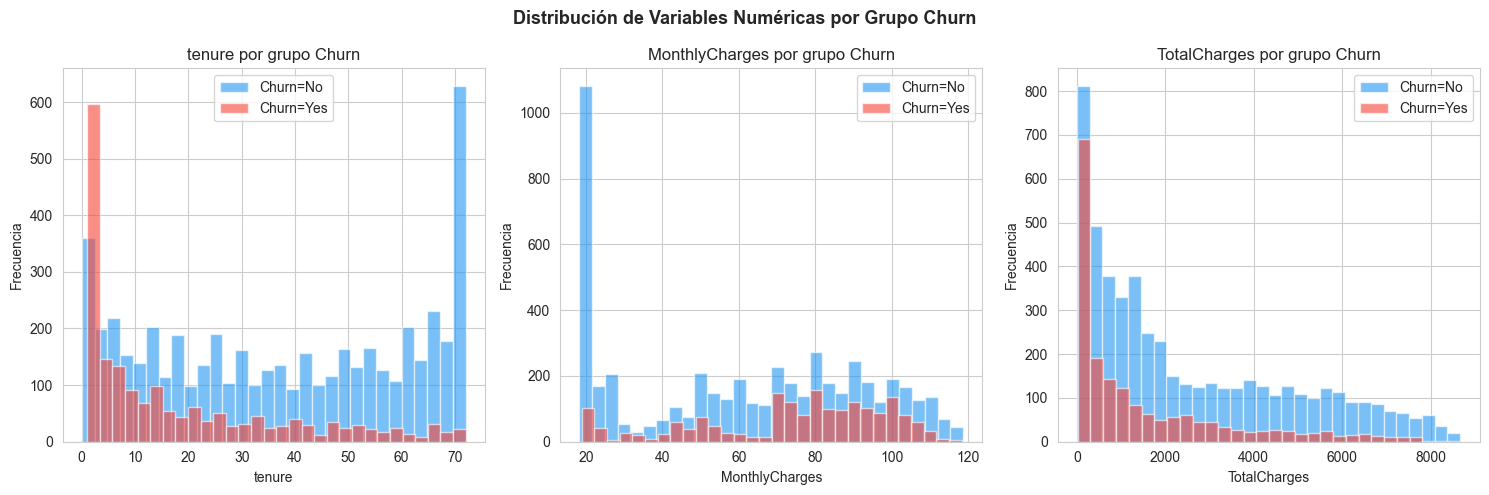

Observación: Los clientes con menor tenure (recientes) tienen mayor tasa de churn.
Los clientes con MonthlyCharges altos también muestran mayor propensión al churn.


In [26]:
# ── VISUALIZACIÓN: Distribución de outliers en contexto ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colores = {'No': '#2196F3', 'Yes': '#F44336'}

for i, var in enumerate(vars_num_completas):
    for churn_val, color in colores.items():
        subset = df[df['Churn'] == churn_val][var]
        axes[i].hist(subset, bins=30, alpha=0.6, color=color, label=f'Churn={churn_val}', edgecolor='white')
    axes[i].set_title(f'{var} por grupo Churn')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend()

plt.suptitle('Distribución de Variables Numéricas por Grupo Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Observación: Los clientes con menor tenure (recientes) tienen mayor tasa de churn.')
print('Los clientes con MonthlyCharges altos también muestran mayor propensión al churn.')

---
## 5. Resumen de acciones de preprocesamiento

A continuación se presenta un resumen de todos los problemas identificados y las acciones aplicadas:


In [27]:
# ── Resumen tabular de cambios ──
resumen = pd.DataFrame({
    'Problema': [
        'Valores faltantes ocultos',
        'Formato incorrecto',
        'Inconsistencia de codificación',
        'Datos duplicados',
        'Valores atípicos'
    ],
    'Variable afectada': [
        'TotalCharges (11 filas con espacio vacío)',
        'TotalCharges (tipo object en lugar de float)',
        'SeniorCitizen (0/1 en lugar de No/Yes)',
        'Ninguna (0 duplicados detectados)',
        'MonthlyCharges, TotalCharges (outliers genuinos)'
    ],
    'Acción aplicada': [
        'Imputación con 0.0 (clientes con tenure=0)',
        'Conversión a float64 con pd.to_numeric()',
        'Mapeo {0:No, 1:Yes} para uniformidad',
        'Verificación realizada, sin eliminaciones',
        'Se conservan (casos reales de alto valor)'
    ],
    'Justificación': [
        'Son clientes nuevos sin cargo acumulado, imputar con 0 es coherente con el dominio',
        'Los algoritmos de ML requieren variables numéricas en formato numérico',
        'Uniformidad facilita la etapa de transformación y la interpretación',
        'No hay riesgo de sesgo por duplicados en este dataset',
        'Los algoritmos basados en árboles son robustos; se normalizará antes de modelos sensibles a escala'
    ]
})

print('RESUMEN DE PREPROCESAMIENTO:')
resumen

RESUMEN DE PREPROCESAMIENTO:


,Problema,Variable afectada,Acción aplicada,Justificación
0,Valores faltantes ocultos,TotalCharges (11 filas con espacio vacío),Imputación con 0.0 (clientes con tenure=0),"Son clientes nuevos sin cargo acumulado, imput..."
1,Formato incorrecto,TotalCharges (tipo object en lugar de float),Conversión a float64 con pd.to_numeric(),Los algoritmos de ML requieren variables numér...
2,Inconsistencia de codificación,SeniorCitizen (0/1 en lugar de No/Yes),"Mapeo {0:No, 1:Yes} para uniformidad",Uniformidad facilita la etapa de transformació...
3,Datos duplicados,Ninguna (0 duplicados detectados),"Verificación realizada, sin eliminaciones",No hay riesgo de sesgo por duplicados en este ...
4,Valores atípicos,"MonthlyCharges, TotalCharges (outliers genuinos)",Se conservan (casos reales de alto valor),Los algoritmos basados en árboles son robustos...


In [28]:
# ── Estado del dataset: antes vs después ──
print('Dataset limpio — Estado final:')
print(f'  Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas')
print(f'  Valores nulos: {df.isnull().sum().sum()}')
print(f'  Filas duplicadas: {df.duplicated().sum()}')
print()
print('Tipos de datos finales:')
print(df.dtypes.to_string())

Dataset limpio — Estado final:
  Dimensiones: 7043 filas × 21 columnas
  Valores nulos: 0
  Filas duplicadas: 0

Tipos de datos finales:
customerID           object
gender               object
SeniorCitizen        object
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object


In [29]:
# ── Guardar el dataset limpio ──
df.to_csv('datasets/telco_churn_limpio.csv', index=False)
print('✓ Dataset limpio guardado como: telco_churn_limpio.csv')
print(f'  Listo para la etapa de Transformación y Minería de Datos.')

✓ Dataset limpio guardado como: telco_churn_limpio.csv
  Listo para la etapa de Transformación y Minería de Datos.


---
## 6. Próximos pasos hacia la Minería de Datos

El dataset ya está limpio. Antes de aplicar los algoritmos de clasificación, quedan dos etapas del proceso KDD:

### Etapa de Transformación

| Tarea | Variables implicadas | Técnica |
|---|---|---|
| Codificación de variables categóricas | gender, Partner, Dependents, Contract, PaymentMethod... | Label Encoding / One-Hot Encoding |
| Normalización de variables numéricas | tenure, MonthlyCharges, TotalCharges | MinMaxScaler / StandardScaler |
| Creación de nuevas variables (opcional) | tenure + MonthlyCharges | Feature Engineering |
| División train/test | Todas | train_test_split (80/20) |
| Balanceo de clases (opcional) | Churn (26.5% vs 73.5%) | SMOTE u oversampling |

### Etapa de Minería de Datos

**Tarea:** Clasificación binaria → predecir `Churn = Yes / No`

**Algoritmos candidatos:**
- Árbol de Decisión (interpretable, robusto a outliers)
- Regresión Logística (línea base, requiere normalización)
- Random Forest (potente, menos interpretable)
- KNN (simple, sensible a escala y dimensionalidad)

**Métricas de evaluación:**
- Accuracy, Precision, Recall, F1-Score
- Matriz de confusión
- AUC-ROC

> **Reflexión final:** Cada decisión de preprocesamiento tomada en este notebook tiene un impacto directo en la calidad del modelo final.  
> Un dato mal tratado puede degradar el rendimiento del mejor algoritmo. El preprocesamiento no es un paso secundario: es la base del conocimiento que se va a extraer.


In [30]:
# Vista previa del dataset limpio y listo para la siguiente etapa
print('Dataset limpio — primeras filas:')
df.head()

Dataset limpio — primeras filas:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
